# MovieLens Exploratory Data Analysis

## Objective

Explore the processed MovieLens catalogue to understand movie metadata,
genre distribution, release-year coverage, and data quality.

In [30]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

print("EDA environment is ready.")

current_directory = Path.cwd()
print(current_directory)

EDA environment is ready.
f:\MovieMate-AI\notebooks


## Load Processed Movie Catalogue

In [31]:
PROJECT_ROOT = current_directory.parent

processed_data_path = (
    PROJECT_ROOT / "data" / "processed" / "movies_processed.csv"
)

movies = pd.read_csv(processed_data_path)

print(f"Dataset shape: {movies.shape}")
movies.head()

Dataset shape: (62423, 8)


,movieId,title,genres,tmdbId,release_year,clean_title,genres_text,genre_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,862.0,1995.0,Toy Story,Adventure Animation Children Comedy Fantasy,5
1,2,Jumanji (1995),Adventure|Children|Fantasy,8844.0,1995.0,Jumanji,Adventure Children Fantasy,3
2,3,Grumpier Old Men (1995),Comedy|Romance,15602.0,1995.0,Grumpier Old Men,Comedy Romance,2
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,31357.0,1995.0,Waiting to Exhale,Comedy Drama Romance,3
4,5,Father of the Bride Part II (1995),Comedy,11862.0,1995.0,Father of the Bride Part II,Comedy,1


## Data Types and Missing Values

In [32]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movieId       62423 non-null  int64  
 1   title         62423 non-null  object 
 2   genres        57361 non-null  object 
 3   tmdbId        62316 non-null  float64
 4   release_year  61857 non-null  float64
 5   clean_title   62423 non-null  object 
 6   genres_text   57361 non-null  object 
 7   genre_count   62423 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 3.8+ MB


In [33]:
missing_values = movies.isna().sum().sort_values(ascending=False)

missing_values[missing_values>0]

genres          5062
genres_text     5062
release_year     566
tmdbId           107
dtype: int64

## Genre Distribution

In [34]:
genre_counts = (
    movies["genres"]
    .dropna()
    .str.split("|")
    .explode()
    .value_counts()
)

genre_counts.head(10)

genres
Drama          25606
Comedy         16870
Thriller        8654
Romance         7719
Action          7348
Horror          5989
Documentary     5605
Crime           5319
Adventure       4145
Sci-Fi          3595
Name: count, dtype: int64

### Top 10 Most Common Genres

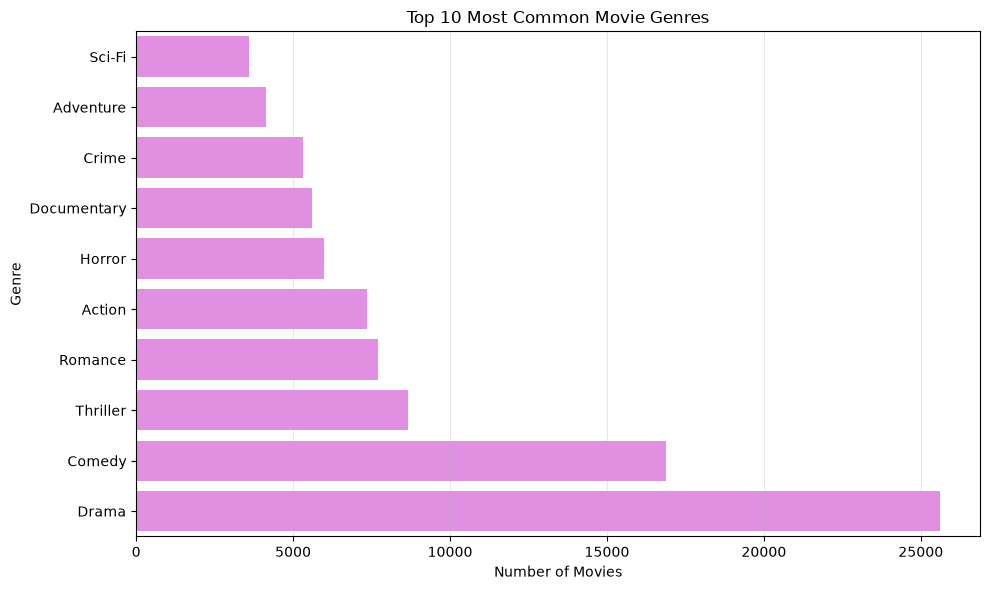

In [35]:
top_genres = genre_counts.head(10).sort_values()

plt.close()
plt.figure(figsize=(10,6))

sns.barplot(
    x = top_genres.values,
    y = top_genres.index,
    color="violet"
)

plt.title("Top 10 Most Common Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


**Insight:** Drama is the most common genre in the MovieLens catalogue, followed by Comedy and Thriller. The distribution is imbalanced, which may influence recommendation popularity and model behaviour.

## Release Year Analysis

In [36]:
release_years = movies["release_year"].dropna()

print(f"Movies with a known release year: {len(release_years):,}")
print(f"Earliest release year: {release_years.min():.0f}")
print(f"Latest release year: {release_years.max():.0f}")

release_years.describe()

Movies with a known release year: 61,857
Earliest release year: 1874
Latest release year: 2019


count    61857.000000
mean      1992.033125
std         25.375008
min       1874.000000
25%       1976.000000
50%       2002.000000
75%       2012.000000
max       2019.000000
Name: release_year, dtype: float64

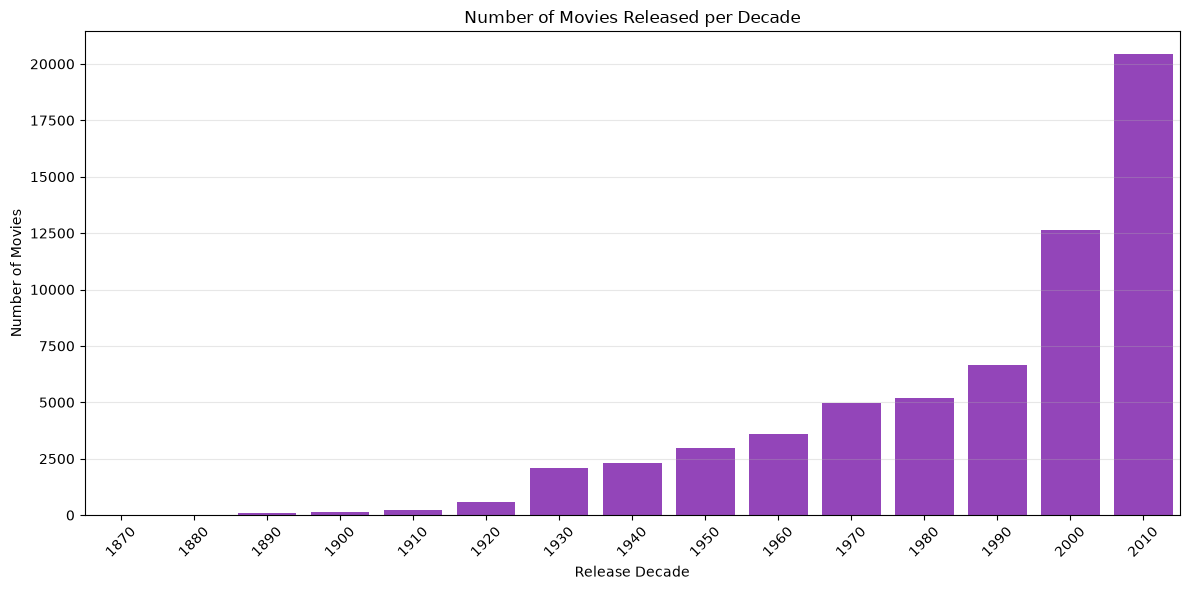

In [37]:
movies_with_year = movies.dropna(subset=["release_year"]).copy()

movies_with_year["release_decade"] = (
    (movies_with_year["release_year"] // 10) * 10
).astype("Int64")

movies_per_decade = (
    movies_with_year["release_decade"]
    .value_counts()
    .sort_index()
)

plt.close()
plt.figure(figsize=(12,6))

sns.barplot(
    x=movies_per_decade.index.astype(str),
    y=movies_per_decade.values,
    color="darkorchid"
)

plt.title("Number of Movies Released per Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** The MovieLens catalogue contains substantially more recent movies, with the 2010s being the most represented decade. This temporal imbalance should be considered when interpreting recommendation popularity.

## Number of Genres per Movie

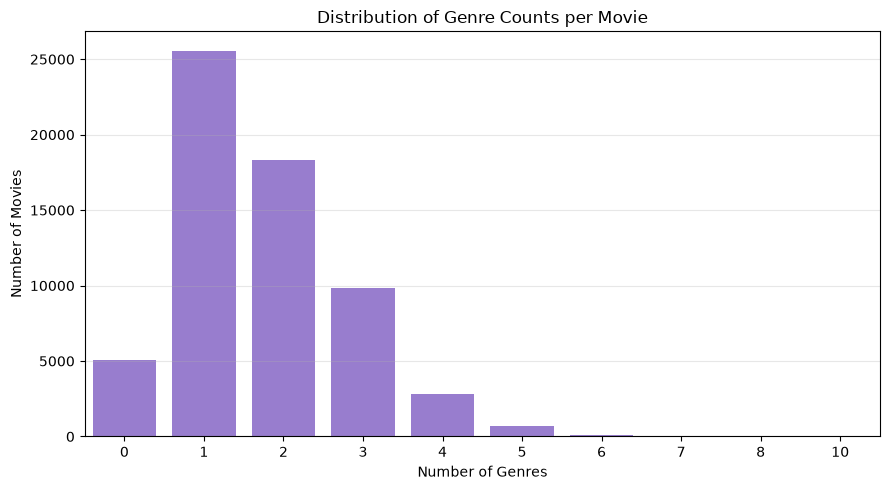

In [38]:
genre_count_distribution=(
    movies["genre_count"]
    .value_counts()
    .sort_index()
)

plt.close()
plt.figure(figsize=(9,5))

sns.barplot(
    x=genre_count_distribution.index,
    y= genre_count_distribution.values,
    color= "mediumpurple"
)

plt.title("Distribution of Genre Counts per Movie")
plt.xlabel("Number of Genres")
plt.ylabel("Number of Movies")
plt.grid(axis="y" , alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** Excluding movies with missing genre information, most movies are labelled with one or two genres. Movies with many genre labels are comparatively rare, which affects how much genre-based similarity can be inferred for each title.

## Ratings Dataset Overview

In [39]:
ratings_path = (
    PROJECT_ROOT / "data" / "raw" / "ml-25m" / "ratings.csv"
)

ratings_size_mb = ratings_path.stat().st_size / (1024 ** 2)

print(f"Ratings file size: {ratings_size_mb:.2f} MB")


Ratings file size: 646.84 MB


### Rating Distribution with Chunked Processing

In [40]:
rating_counts = pd.Series(dtype="int64")
total_ratings = 0

for chunk in pd.read_csv(
    ratings_path , 
    usecols=["rating"],
    chunksize=1_000_000
):
    total_ratings += len(chunk)
    
    chunk_rating_counts = chunk["rating"].value_counts()
    
    rating_counts = rating_counts.add(
        chunk_rating_counts,
        fill_value=0
    )
    
rating_counts = rating_counts.sort_index().astype(int)
print(f"Total ratings processed: {total_ratings:,}")
rating_counts

Total ratings processed: 25,000,095


rating
0.5     393068
1.0     776815
1.5     399490
2.0    1640868
2.5    1262797
3.0    4896928
3.5    3177318
4.0    6639798
4.5    2200539
5.0    3612474
dtype: int64

### Rating Distribution

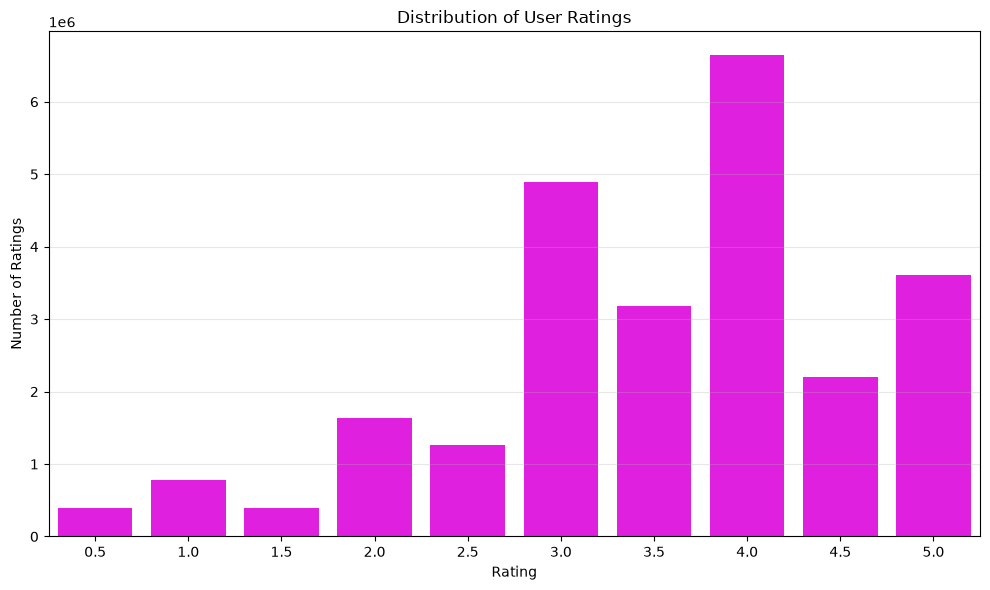

In [41]:
plt.close()
plt.figure(figsize=(10,6))

sns.barplot(
    x = rating_counts.index.astype(str),
    y = rating_counts.values,
    color = "Fuchsia"
)

plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
ratings_3_or_higher = rating_counts[
    rating_counts.index >= 3.0
].sum()

share_3_or_higher = (
    ratings_3_or_higher / total_ratings
) * 100

rating_values = rating_counts.index.to_numpy()
rating_frequencies = rating_counts.to_numpy()

weighted_rating_sum = (
    rating_values * rating_frequencies
).sum()

average_rating = weighted_rating_sum / total_ratings

print(f"Ratings of 3.0 or higher: {share_3_or_higher:.2f}%")
print(f"Average rating: {average_rating:.2f}")

Ratings of 3.0 or higher: 82.11%
Average rating: 3.53


**Insight:** 82.11% of ratings are 3.0 or higher, and the weighted average rating is 3.53 out of 5. This positive skew should be considered when interpreting user preferences and building collaborative filtering models.